# 🩺 Diabetes Prediction — AdaBoost Classifier (Ensemble / Boosting)

**🇹🇷 Türkçe:**
Bu notebook, **Pima Indians Diabetes** veri seti üzerinde bir kişinin diyabet hastası olup olmadığını (`Outcome`: 0 / 1) tahmin eden bir **AdaBoost** sınıflandırıcısı kuruyor. Veri seti 768 hastaya ait gebelik sayısı, glikoz, kan basıncı, insülin, BMI gibi 8 tıbbi ölçümü içeriyor.

**AdaBoost (Adaptive Boosting)** bir *boosting* yöntemidir: Random Forest gibi ağaçları birbirinden bağımsız ve paralel kurmak yerine, ağaçları **sırayla** kurar. Her yeni zayıf öğrenici (varsayılan olarak `max_depth=1` olan bir *decision stump*), bir öncekinin **yanlış sınıflandırdığı** örneklere daha fazla ağırlık vererek eğitilir. Böylece model, adım adım zor örneklere odaklanır ve zayıf öğrenicilerin ağırlıklı oyu güçlü bir sınıflandırıcı oluşturur.

Notebook; gizli eksik değerlerin (0 olarak kodlanmış) tespiti, `SimpleImputer` ile doldurulması, IQR yöntemiyle aykırı değer temizliği, ölçekleme, model kurulumu ve `GridSearchCV` ile hiperparametre optimizasyonunu kapsıyor.

**🇬🇧 English:**
This notebook builds an **AdaBoost** classifier on the **Pima Indians Diabetes** dataset to predict whether a patient has diabetes (`Outcome`: 0 / 1). The dataset holds 8 medical measurements — pregnancies, glucose, blood pressure, insulin, BMI and more — for 768 patients.

**AdaBoost (Adaptive Boosting)** is a *boosting* method: instead of growing trees independently and in parallel like a Random Forest, it grows them **sequentially**. Each new weak learner (by default a `max_depth=1` *decision stump*) is trained with higher weights on the samples the previous one **misclassified**. The model therefore focuses on the hard cases step by step, and the weighted vote of the weak learners forms a strong classifier.

The notebook covers detecting hidden missing values (encoded as 0), imputing them with `SimpleImputer`, removing outliers with the IQR rule, scaling, model fitting, and hyperparameter tuning via `GridSearchCV`.

## 📦 0. Kütüphaneler / Imports

**🇹🇷 Türkçe:**
Veri işleme, sayısal hesaplama ve görselleştirme için gereken temel kütüphaneler tek hücrede toplanıyor.

**🇬🇧 English:**
The core libraries for data handling, numeric computation, and visualization are collected in a single cell.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Pima Indians Diabetes veri seti CSV dosyasından okunuyor. Hedef değişken `Outcome`: 1 = diyabet var, 0 = diyabet yok.

**🇬🇧 English:**
The Pima Indians Diabetes dataset is read from CSV. The target variable is `Outcome`: 1 = diabetic, 0 = non-diabetic.

In [2]:
df = pd.read_csv("../../Data/16-diabetes.csv")

## 🔍 2. Veriye İlk Bakış / First Look at the Data

**🇹🇷 Türkçe:**
`head()`, `isnull()`, `unique()` ve `describe()` ile veri setinin genel yapısı inceleniyor.

Buradaki en kritik gözlem `describe()` çıktısında saklı: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin` ve `BMI` kolonlarının **minimum değeri 0**. Bir insanın kan basıncının veya vücut kitle indeksinin 0 olması fizyolojik olarak imkânsız. Yani `isnull()` "eksik değer yok" dese de, bu veri setinde eksik değerler `NaN` yerine **0 olarak kodlanmış**. Bu tür "gizli eksik değerler" sadece `isnull()` sayısına bakılarak fark edilemez — dağılımı incelemek gerekir.

**🇬🇧 English:**
`head()`, `isnull()`, `unique()`, and `describe()` are used to inspect the overall structure of the dataset.

The most important observation is hidden in the `describe()` output: the **minimum value is 0** for `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI`. A blood pressure or body-mass index of zero is physiologically impossible. So even though `isnull()` reports no missing values, missing entries in this dataset are **encoded as 0 rather than `NaN`**. Such "hidden missing values" cannot be caught by looking at `isnull()` counts alone — the distributions have to be inspected.

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [5]:
for col in df.columns:
    print("Column: ", col, "\n")
    print(df[col].unique(), "\n")

Column:  Pregnancies 

[ 6  1  8  0  5  3 10  2  4  7  9 11 13 15 17 12 14] 

Column:  Glucose 

[148  85 183  89 137 116  78 115 197 125 110 168 139 189 166 100 118 107
 103 126  99 196 119 143 147  97 145 117 109 158  88  92 122 138 102  90
 111 180 133 106 171 159 146  71 105 101 176 150  73 187  84  44 141 114
  95 129  79   0  62 131 112 113  74  83 136  80 123  81 134 142 144  93
 163 151  96 155  76 160 124 162 132 120 173 170 128 108 154  57 156 153
 188 152 104  87  75 179 130 194 181 135 184 140 177 164  91 165  86 193
 191 161 167  77 182 157 178  61  98 127  82  72 172  94 175 195  68 186
 198 121  67 174 199  56 169 149  65 190] 

Column:  BloodPressure 

[ 72  66  64  40  74  50   0  70  96  92  80  60  84  30  88  90  94  76
  82  75  58  78  68 110  56  62  85  86  48  44  65 108  55 122  54  52
  98 104  95  46 102 100  61  24  38 106 114] 

Column:  SkinThickness 

[35 29  0 23 32 45 19 47 38 30 41 33 26 15 36 11 31 37 42 25 18 24 39 27
 21 34 10 60 13 20 22 28 54 40 

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 📊 3. Görselleştirme / Visualization

**🇹🇷 Türkçe:**
Her kolon için `countplot` ve `boxplot` çizdirilerek dağılımlar ve aykırı değerler görsel olarak inceleniyor. Boxplot'lar, birazdan IQR yöntemiyle temizlenecek aykırı değerlerin nerede yoğunlaştığını gösteriyor.

**🇬🇧 English:**
A `countplot` and a `boxplot` are drawn for every column to inspect distributions and outliers visually. The boxplots show where the outliers — cleaned later with the IQR rule — are concentrated.

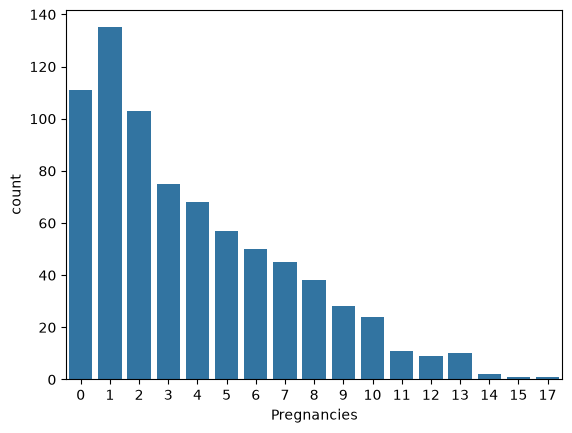

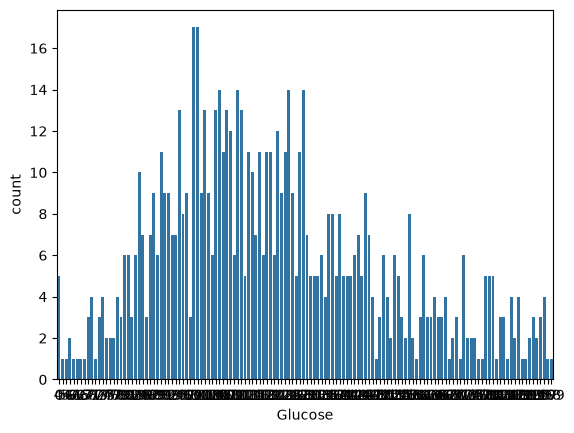

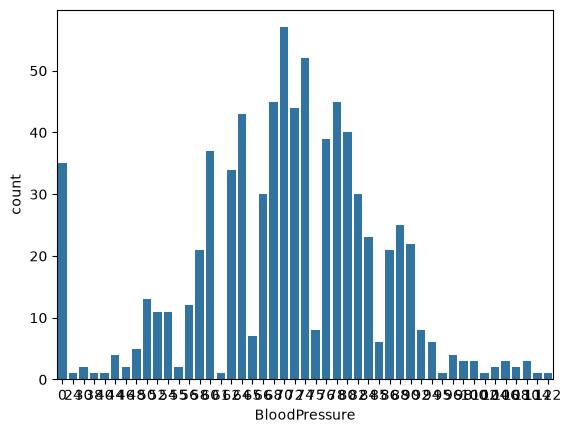

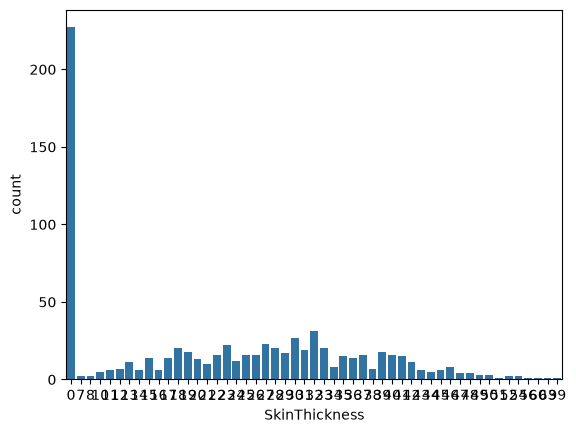

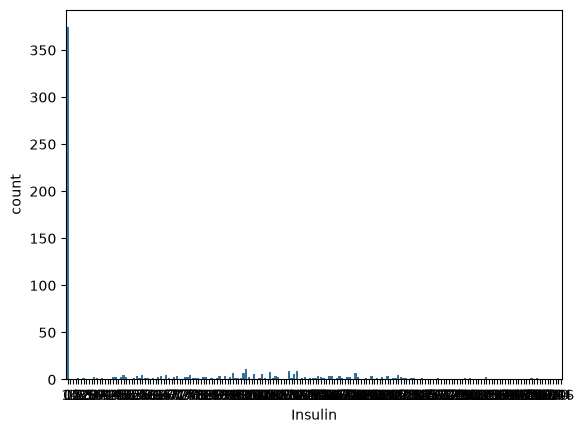

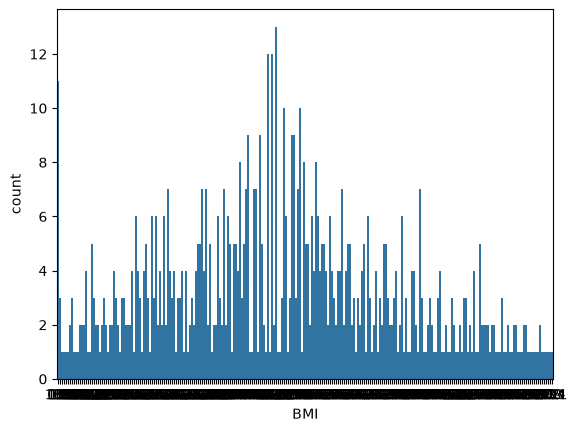

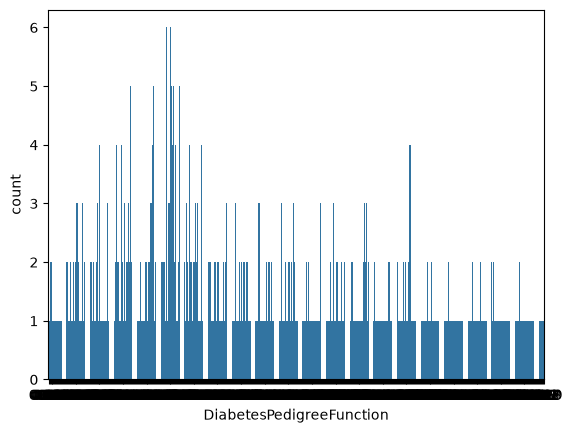

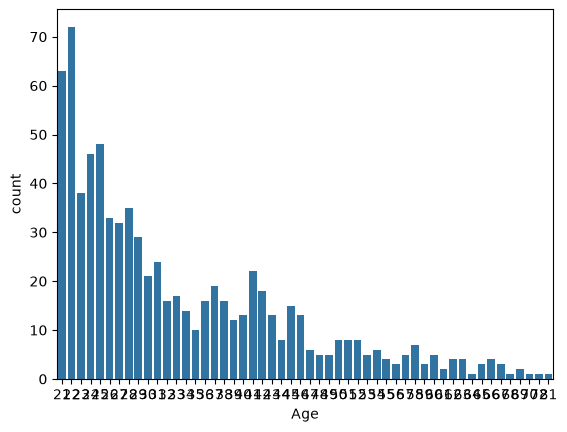

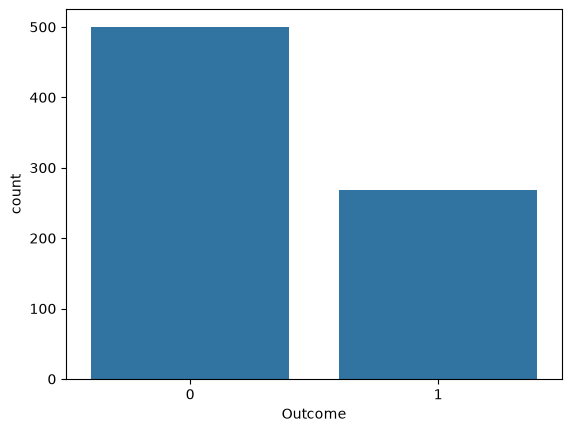

In [7]:
for i in df.columns:
    sns.countplot(x=i, data=df)
    plt.show()

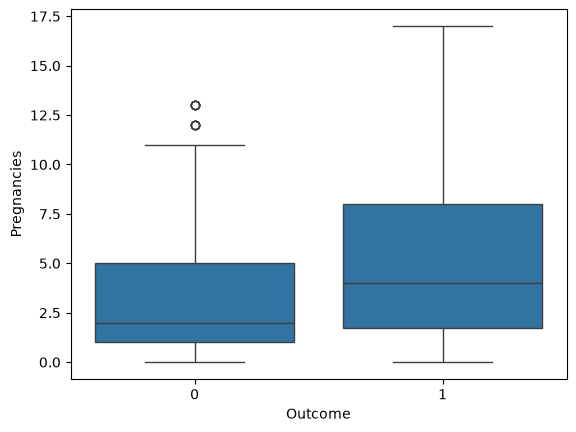

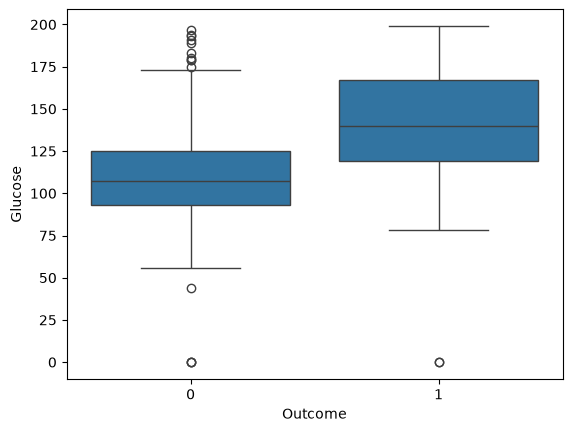

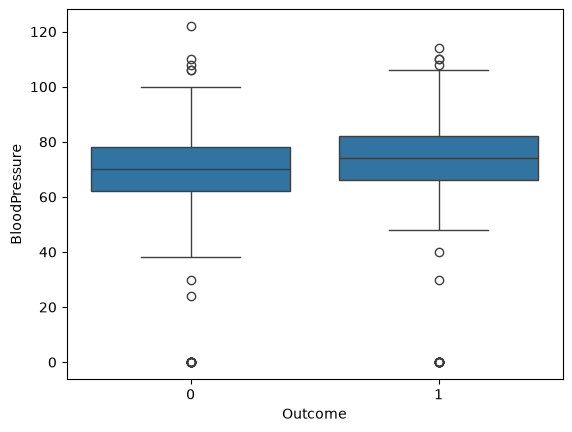

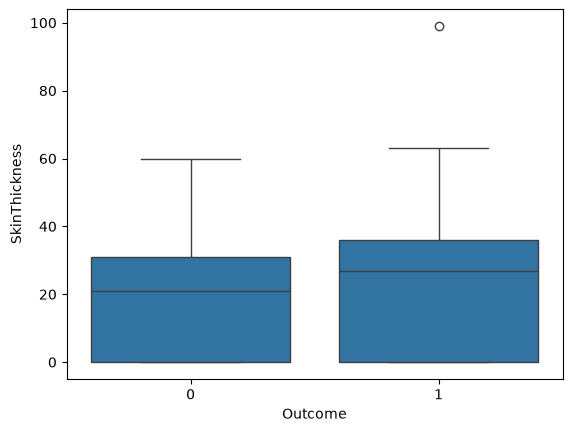

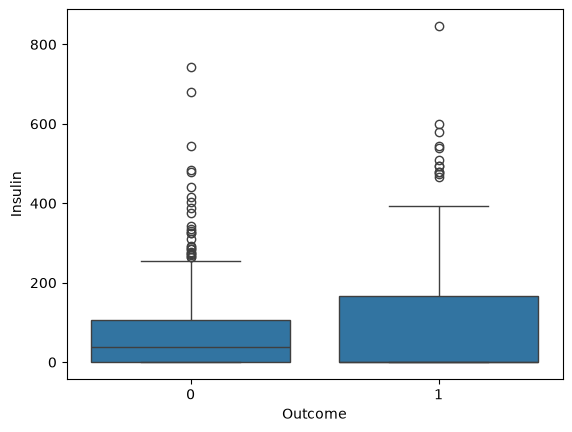

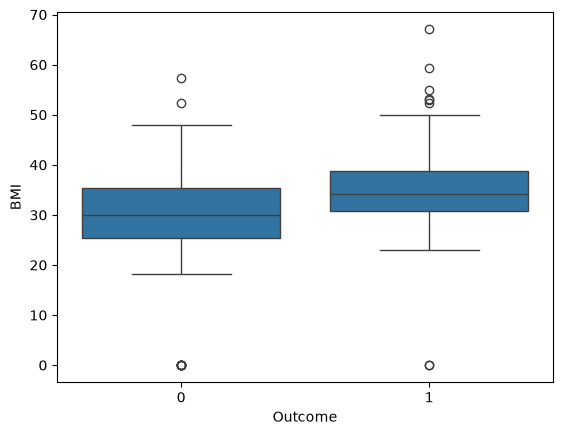

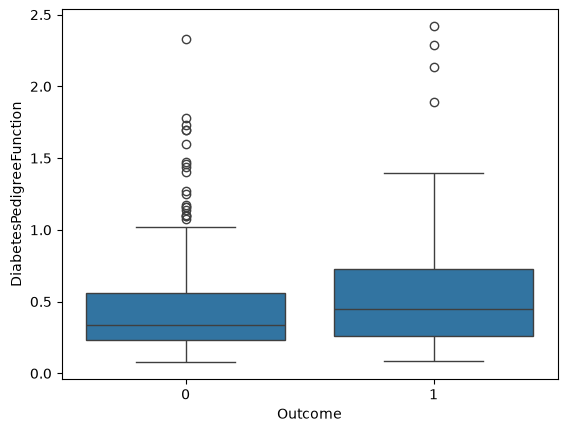

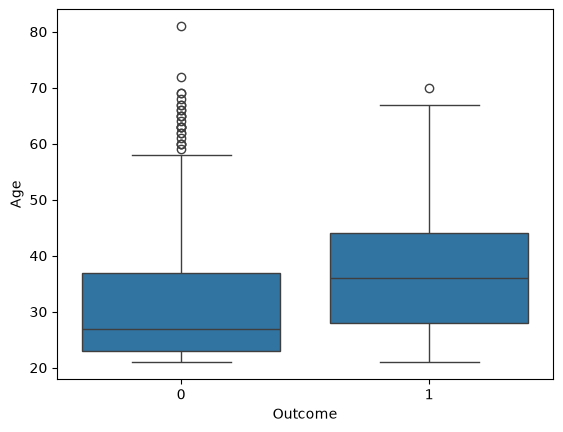

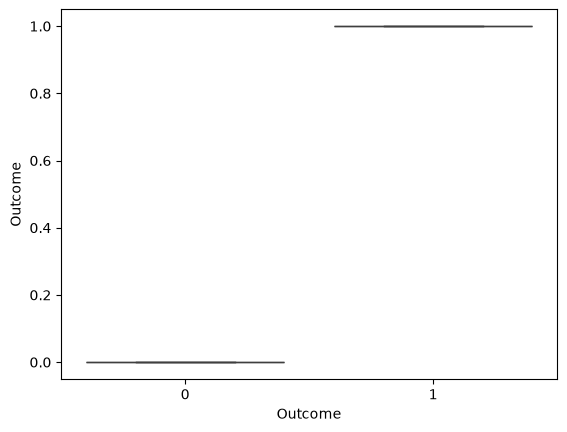

In [8]:
for col in df.columns:
    sns.boxplot(x=i, y=col, data=df)
    plt.show()

## 🕳️ 4. Gizli Eksik Değerler: 0'ları `NaN` Yapmak / Hidden Missing Values

**🇹🇷 Türkçe:**
Fizyolojik olarak imkânsız olan 0 değerleri `NaN`'a çevriliyor ki `isnull()` gerçek eksik veri tablosunu gösterebilsin. Sonuç çarpıcı: `Insulin` kolonunun **374 satırı** (yaklaşık %49'u) ve `SkinThickness` kolonunun **227 satırı** aslında eksikmiş.

⚠️ **Dikkat edilmesi gereken nokta:** Burada dönüşüm `df.columns` üzerinde döngüyle **tüm kolonlara** uygulanıyor. Ancak `Pregnancies` ve `Outcome` kolonlarında 0 **geçerli bir değerdir** — hiç doğum yapmamış bir kadın ya da diyabet olmayan bir hasta. Bu yüzden `Outcome` bir sonraki hücrede tekrar 0'a döndürülüyor. `Pregnancies` kolonundaki 111 sıfır ise eksik sayılıp ortalamayla dolduruluyor; daha titiz bir yaklaşımda dönüşüm sadece `["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]` kolonlarına uygulanmalıydı.

**🇬🇧 English:**
The physiologically impossible zeros are converted to `NaN` so that `isnull()` can reveal the true missing-data picture. The result is striking: **374 rows** of `Insulin` (roughly 49%) and **227 rows** of `SkinThickness` were in fact missing.

⚠️ **A caveat worth flagging:** the replacement is applied to **every column** by looping over `df.columns`. But 0 is a **legitimate value** in `Pregnancies` and `Outcome` — a woman who has never given birth, or a patient without diabetes. That is why `Outcome` is restored to 0 in the next cell. The 111 zeros in `Pregnancies`, however, are treated as missing and filled with the mean; a stricter approach would have applied the replacement only to `["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]`.

In [9]:
for i in df.columns:
    df[i] = df[i].replace(0, np.nan)

In [10]:
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

In [11]:
df["Outcome"] = df["Outcome"].replace(np.nan, 0)

In [12]:
df.isnull().sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 🔧 5. Eksik Değerlerin Doldurulması / Imputation with `SimpleImputer`

**🇹🇷 Türkçe:**
Eksik değerler `SimpleImputer(strategy="mean")` ile kolon ortalamalarıyla dolduruluyor. Imputer bir `Pipeline` içine, o da bir `ColumnTransformer` içine yerleştiriliyor — bu, ileride daha karmaşık ön işleme adımları eklenebilecek modüler bir yapı sağlıyor.

`ColumnTransformer.fit_transform()` isimsiz bir NumPy array döndürdüğü için, çıktı `pd.DataFrame(..., columns=columns_df)` ile tekrar isimli bir DataFrame'e sarılıyor.

**🇬🇧 English:**
Missing values are filled with column means via `SimpleImputer(strategy="mean")`. The imputer sits inside a `Pipeline`, which in turn sits inside a `ColumnTransformer` — a modular structure that leaves room for more preprocessing steps later.

Since `ColumnTransformer.fit_transform()` returns an unnamed NumPy array, the output is wrapped back into a named DataFrame with `pd.DataFrame(..., columns=columns_df)`.

In [13]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [14]:
columns_df = df.columns.tolist()

In [15]:
nan_pipeline = Pipeline([("imputer", SimpleImputer(strategy="mean"))])
nan_col_trans = ColumnTransformer([("nan_trans", nan_pipeline, columns_df)])

In [16]:
df_imputed = nan_col_trans.fit_transform(df)
df = pd.DataFrame(df_imputed, columns=columns_df)

In [17]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    float64
 1   Glucose                   768 non-null    float64
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    float64
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    float64
 8   Outcome                   768 non-null    float64
dtypes: float64(9)
memory usage: 54.1 KB


In [19]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,4.494673,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,2.975395,30.435949,12.096346,8.790942,85.021108,6.875151,0.331329,11.760232,0.476951
min,1.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,2.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,4.494673,117.000000,72.202592,29.153420,155.548223,32.400000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,155.548223,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## ✂️ 6. Aykırı Değer Temizliği: IQR Yöntemi / Outlier Removal with IQR

**🇹🇷 Türkçe:**
Aykırı değerler **IQR (Interquartile Range)** kuralıyla temizleniyor:

```
IQR = Q3 - Q1
Alt sınır = Q1 - 1.5 × IQR
Üst sınır = Q3 + 1.5 × IQR
```

Bu sınırların dışında kalan satırlar veri setinden çıkarılıyor. AdaBoost gibi boosting algoritmaları aykırı değerlere **özellikle duyarlıdır**, çünkü algoritma yanlış tahmin edilen örneklerin ağırlığını her turda artırır — uç bir gürültü noktası, modelin sonraki tüm adımlarını kendine çekebilir. Bu yüzden boosting öncesi aykırı değer temizliği anlamlı bir adım.

**🇬🇧 English:**
Outliers are removed with the **IQR (Interquartile Range)** rule:

```
IQR = Q3 - Q1
Lower bound = Q1 - 1.5 × IQR
Upper bound = Q3 + 1.5 × IQR
```

Rows falling outside these bounds are dropped. Boosting algorithms like AdaBoost are **particularly sensitive** to outliers, because the algorithm increases the weight of misclassified samples at every round — a single extreme noise point can pull all subsequent steps toward itself. Cleaning outliers before boosting is therefore a meaningful step.

In [20]:
for i in df.columns:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3 - Q1

    alt_sinir = Q1 - 1.5 * IQR
    ust_sinir = Q3 + 1.5 * IQR

    df = df[(df[i] >= alt_sinir) & (df[i] <= ust_sinir)]

## 🌡️ 7. Korelasyon Analizi / Correlation Heatmap

**🇹🇷 Türkçe:**
Özellikler arasındaki doğrusal ilişkiler ve her özelliğin hedefle (`Outcome`) korelasyonu ısı haritasıyla inceleniyor.

**🇬🇧 English:**
The linear relationships between features, and each feature's correlation with the target (`Outcome`), are inspected with a heatmap.

<Axes: >

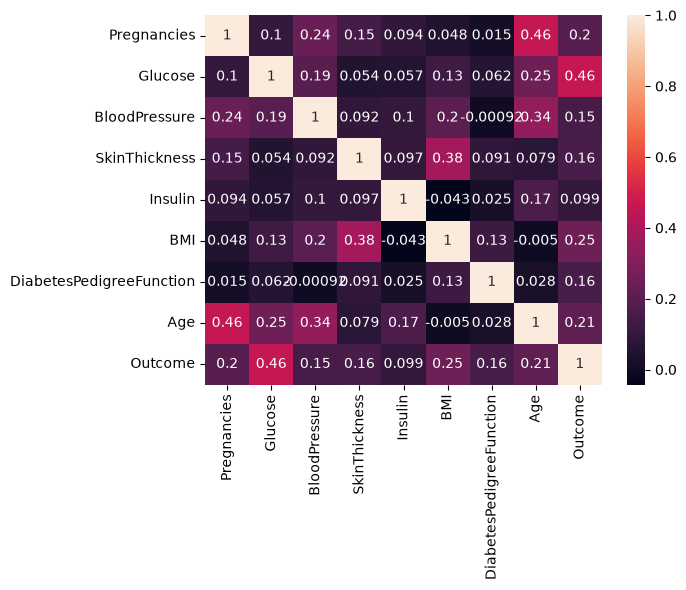

In [21]:
sns.heatmap(df.corr(), annot=True)

## ⚖️ 8. Ölçekleme ve Train/Test Ayrımı / Scaling & Train-Test Split

**🇹🇷 Türkçe:**
Veri önce `X` (özellikler) ve `y` (hedef) olarak ayrılıyor, ardından %80 eğitim / %20 test olarak bölünüyor. `StandardScaler` **sadece eğitim setinde `fit`** ediliyor, test setine yalnızca `transform` uygulanıyor — bu, test setinin istatistiklerinin modele sızmasını (data leakage) önleyen temel disiplin.

ℹ️ **Not:** Ağaç tabanlı modeller (dolayısıyla varsayılan AdaBoost) ölçeklemeye ihtiyaç duymaz, çünkü karar ağaçları eşik değerine göre bölme yapar ve bu bölmeler ölçekten bağımsızdır. Buradaki ölçekleme zararsızdır ancak bu model için zorunlu değildir.

⚠️ **Kaçırılmaması gereken bir ayrıntı:** Yukarıdaki imputation ve IQR temizliği train/test ayrımından **önce** tüm veri setine uygulandı. Bu teknik olarak hafif bir sızıntıdır — ortalama değerler test satırlarını da görmüş olur. Tamamen sızıntısız bir kurulumda bu adımların da `Pipeline` içine alınıp her fold'da yeniden `fit` edilmesi gerekir.

**🇬🇧 English:**
The data is first separated into `X` (features) and `y` (target), then split 80% train / 20% test. `StandardScaler` is **fit on the training set only**, and merely `transform`ed onto the test set — the basic discipline that prevents test-set statistics from leaking into the model.

ℹ️ **Note:** Tree-based models (and therefore the default AdaBoost) do not need scaling, since decision trees split on thresholds and those splits are scale-invariant. The scaling here is harmless but not required for this model.

⚠️ **A detail worth noticing:** the imputation and IQR cleaning above were applied to the whole dataset **before** the train/test split. That is technically a mild leak — the means have seen the test rows too. In a fully leakage-free setup those steps would also live inside a `Pipeline` and be refit on every fold.

In [22]:
from sklearn.preprocessing import StandardScaler

In [23]:
scaler = StandardScaler()

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [28]:
X_train

array([[ 1.94000461,  0.14873895, -0.24466615, ..., -0.12865804,
        -0.80956435,  0.57016464],
       [-0.24312019, -1.55552852, -0.99577024, ...,  0.36419859,
        -0.01889552, -0.76934277],
       [-0.60697432,  0.14873895, -1.37132229, ..., -0.04368276,
        -1.03911336, -0.85306198],
       ...,
       [-1.33468259, -0.44253752,  1.44531805, ..., -0.8084603 ,
         0.01936265, -0.85306198],
       [-0.97082846, -0.75556624, -1.18354626, ...,  0.80607006,
         0.24466076, -1.10421962],
       [ 0.48458808, -0.65122333,  0.88198999, ..., -0.17964321,
        -0.91583704,  0.15156858]], shape=(364, 8))

## 🚀 9. AdaBoost Modelinin Kurulması / Training the AdaBoost Classifier

**🇹🇷 Türkçe:**
`AdaBoostClassifier` varsayılan parametrelerle kuruluyor: 50 tane `max_depth=1` karar ağacı (decision stump), `learning_rate=1.0`. Her stump yalnızca tek bir özelliğe tek bir eşik uygular — tek başına neredeyse rastgele tahminden biraz iyidir, ama 50 tanesinin ağırlıklı oyu güçlü bir sınıflandırıcıya dönüşür.

**🇬🇧 English:**
`AdaBoostClassifier` is fit with its default parameters: 50 `max_depth=1` decision trees (stumps) and `learning_rate=1.0`. Each stump applies a single threshold on a single feature — barely better than random on its own, but the weighted vote of 50 of them becomes a strong classifier.

In [29]:
from sklearn.ensemble import AdaBoostClassifier

In [30]:
ada_clf = AdaBoostClassifier()

In [31]:
ada_clf.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[float64](2,)","[0.,1.]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.29,0.36,0.34,...,0.48,0.48,0.48]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.89,0.6 ,0.67,...,0.06,0.06,0.06]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1564392163), DecisionTreeC...te=1156004282), DecisionTreeC...ate=454397807), DecisionTreeC...ate=681714120), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](8,)","[0.04,0.36,0. ,...,0.28,0.03,0.14]"


In [32]:
y_pred = ada_clf.predict(X_test)

## 📈 10. Model Değerlendirmesi / Model Evaluation

**🇹🇷 Türkçe:**
Model `accuracy_score`, `confusion_matrix` ve `classification_report` ile değerlendiriliyor.

Burada **accuracy tek başına yanıltıcıdır**: veri setinde sınıf dengesizliği var (çoğunluk sınıfı `Outcome=0`). Modelin genel doğruluğu makul görünse de, `classification_report`'ta pozitif sınıfın (`Outcome=1`, diyabet var) **recall** değerine bakmak gerekir — tıbbi bir teşhis probleminde hasta olan birini "sağlıklı" diye etiketlemek (false negative), tersinden çok daha maliyetlidir.

**🇬🇧 English:**
The model is evaluated with `accuracy_score`, `confusion_matrix`, and `classification_report`.

**Accuracy alone is misleading here**: the dataset is imbalanced (the majority class is `Outcome=0`). Even if overall accuracy looks reasonable, the **recall** of the positive class (`Outcome=1`, diabetic) in the `classification_report` is what matters — in a medical diagnosis problem, labelling a sick patient as "healthy" (a false negative) is far costlier than the reverse.

In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [34]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7391304347826086
[[53  5]
 [19 15]]
              precision    recall  f1-score   support

         0.0       0.74      0.91      0.82        58
         1.0       0.75      0.44      0.56        34

    accuracy                           0.74        92
   macro avg       0.74      0.68      0.69        92
weighted avg       0.74      0.74      0.72        92



## 🎛️ 11. Hiperparametre Optimizasyonu / Hyperparameter Tuning with `GridSearchCV`

**🇹🇷 Türkçe:**
`GridSearchCV` ile 5 katlı çapraz doğrulama üzerinden en iyi parametre kombinasyonu aranıyor:

* **`n_estimators`** — kaç zayıf öğrenici sırayla eğitilecek.
* **`learning_rate`** — her öğrenicinin nihai orandaki ağırlığı. Düşük değerler daha yavaş ama daha kararlı öğrenme sağlar; `n_estimators` ile **ters ilişkilidir** (öğrenme oranını düşürürsen genelde ağaç sayısını artırman gerekir).
* **`estimator`** — zayıf öğrenicinin kendisi. Varsayılan `max_depth=1` stump yerine daha derin ağaçlar denenerek modelin ne kadar karmaşıklığa ihtiyaç duyduğu ölçülüyor.

**`scoring="f1"` seçildi, `"accuracy"` değil.** Sınıf dengesizliği nedeniyle accuracy'ye göre optimize etmek, modeli çoğunluk sınıfına yaslanmaya teşvik eder. F1, pozitif sınıftaki precision ve recall'ı birlikte hesaba kattığı için bu problemde daha anlamlı bir optimizasyon hedefidir.

**🇬🇧 English:**
`GridSearchCV` searches for the best parameter combination with 5-fold cross-validation:

* **`n_estimators`** — how many weak learners are trained in sequence.
* **`learning_rate`** — the weight each learner carries in the final vote. Lower values learn more slowly but more stably, and it is **inversely related** to `n_estimators` (lowering the learning rate usually means you need more trees).
* **`estimator`** — the weak learner itself. Deeper trees are tried against the default `max_depth=1` stump to measure how much complexity the problem actually needs.

**`scoring="f1"` was chosen over `"accuracy"`.** Because of the class imbalance, optimizing for accuracy would encourage the model to lean on the majority class. F1 accounts for precision and recall on the positive class together, making it the more meaningful objective here.

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.5, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1),
        DecisionTreeClassifier(max_depth=3),
        DecisionTreeClassifier(max_depth=5),
    ],
}

grid_search = GridSearchCV(
    estimator=AdaBoostClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2,
)

In [36]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator': [DecisionTreeC...r(max_depth=1), DecisionTreeC...r(max_depth=3), ...], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.Se

In [37]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'estimator': DecisionTreeClassifier(max_depth=3), 'learning_rate': 0.01, 'n_estimators': 200}
0.5951012419512679


In [38]:
best_ada_clf = grid_search.best_estimator_
y_pred_best = best_ada_clf.predict(X_test)

print(accuracy_score(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

0.75
[[52  6]
 [17 17]]
              precision    recall  f1-score   support

         0.0       0.75      0.90      0.82        58
         1.0       0.74      0.50      0.60        34

    accuracy                           0.75        92
   macro avg       0.75      0.70      0.71        92
weighted avg       0.75      0.75      0.74        92



## ✅ 12. Sonuç / Conclusion

**🇹🇷 Türkçe:**
Bu notebook boyunca:

* `isnull()`'un yakalayamadığı, **0 olarak kodlanmış gizli eksik değerler** `describe()` çıktısındaki imkânsız minimumlar üzerinden tespit edildi ve `SimpleImputer` ile dolduruldu.
* Boosting'in aykırı değerlere olan hassasiyeti göz önünde bulundurularak **IQR** yöntemiyle uç değerler temizlendi.
* `StandardScaler` yalnızca eğitim setinde `fit` edilerek **veri sızıntısı** engellendi.
* Varsayılan `AdaBoostClassifier` **%73.9 accuracy** verdi, ancak pozitif sınıfın recall'ı yalnızca **0.44**'tü — yani diyabet hastalarının yarısından fazlası kaçırılıyordu.
* `GridSearchCV` (`scoring="f1"`) ile `n_estimators`, `learning_rate` ve zayıf öğrenici derinliği birlikte optimize edildi. Kazanan kombinasyon: `DecisionTreeClassifier(max_depth=3)`, `learning_rate=0.01`, `n_estimators=200`.
* Sonuç **%75.0 accuracy**, pozitif sınıf recall'ı **0.50** ve F1 **0.56 → 0.60**. Kazanım mütevazı: accuracy sadece 1 puan arttı, ancak asıl iyileşme doğru yerde — 6 hasta daha doğru teşhis edildi (17 → 15 false negative). Bu, F1'i optimizasyon hedefi seçmenin somut karşılığı.
* Dengesiz veri setinde accuracy yerine **F1 skoru** optimizasyon hedefi olarak seçildi.

**Geliştirilebilecek yönler:** Imputation ve aykırı değer temizliğinin de `Pipeline` içine alınması (tam sızıntısız kurulum), `stratify=y` ile katmanlı bölme, ve pozitif sınıfın recall'ını artırmak için karar eşiğinin (`predict_proba` üzerinden) ayarlanması.

**🇬🇧 English:**
Over the course of this notebook:

* **Hidden missing values encoded as 0** — invisible to `isnull()` — were caught through the impossible minimums in the `describe()` output and filled with `SimpleImputer`.
* Extreme values were removed with the **IQR** rule, given how sensitive boosting is to outliers.
* **Data leakage** was avoided by fitting `StandardScaler` on the training set only.
* The default `AdaBoostClassifier` reached **73.9% accuracy**, but recall on the positive class was only **0.44** — more than half of the diabetic patients were being missed.
* `n_estimators`, `learning_rate`, and weak-learner depth were tuned together via `GridSearchCV` with `scoring="f1"`. The winning combination was `DecisionTreeClassifier(max_depth=3)`, `learning_rate=0.01`, `n_estimators=200`.
* The result was **75.0% accuracy**, positive-class recall of **0.50**, and F1 rising **0.56 → 0.60**. The gain is modest: accuracy moved by only one point, but the improvement landed where it matters — two more sick patients correctly identified (false negatives 17 → 15). That is the concrete payoff of choosing F1 as the objective.
* **F1 score** was chosen over accuracy as the optimization objective on this imbalanced dataset.

**Possible improvements:** moving imputation and outlier removal inside the `Pipeline` too (a fully leakage-free setup), stratified splitting with `stratify=y`, and tuning the decision threshold via `predict_proba` to raise recall on the positive class.